# Homework 01: First Steps with Linear Regression

#### Due Date: Sunday, September 6th at 11:59pm

#### The normal late policy is described in the DX 603 Syllabus. There will be **no late penalty for this first assignment**, so the final deadline is Friday, September 11th at 11:59pm.

In this homework, you will work through your first complete **supervised machine learning workflow** using a small dataset that relates years of experience to salary.

You will:

- inspect and prepare the dataset;
- identify the input feature $X$ and target $y$;
- create training and test sets;
- fit a `LinearRegression` model;
- visualize the fitted relationship;
- evaluate prediction error on both training and unseen test data; and
- use the fitted model to make a prediction for a new observation.

The goal is not to study linear regression in depth—we will return to it later in the course—but to practice the basic machine learning workflow introduced in Week 1, especially the idea of **generalization** to new, unseen data.

This first assignment will also help you become familiar with the course notebook format, Gradescope submission process, and autograder.

**Grading:**

- All homeworks in DX 603 are worth **80 points**. This homework has 8 problems, each worth 10 points. When a problem has subparts, they are worth the same number of points; e.g., Problem 7 has 5 subproblems, each worth 2 points.
- For the first two homeworks, the autograder will report results immediately after submission, and you may resubmit as many times as you like up to the deadline. The exception is **Problem 8**, which will be graded after the deadline.
- Discussion questions, typically the final problem, will be **AI graded**. When final grades are released after the last deadline on Saturday morning, you will receive a numerical score and AI-generated feedback. We use a **human-in-the-loop** approach: any deductions from the AI grading will be reviewed by a Learning Facilitator or instructor.
- You may submit a **regrade request** on Gradescope after your grades are released. The instructor will review the request and make any appropriate adjustment.
  
---

### Submission Instructions via Gradescope

We will use Gradescope for homework submissions this term. Please follow these instructions carefully.

#### 1. Do not modify grading cells

Do **not** make any changes to cells containing grading code, such as:

```python
# Graded Answer
# DO NOT change this cell in any way
# Be SURE to run this cell before submitting


print(f'a1 = {a1}')
```

You should make changes only in cells marked with instructions such as:

```python
# Your code here
```

or

```python
# Your answer here, NOT in the next cell
```

#### 2. Complete and verify your notebook

Some cells in the starter notebook are intentionally incomplete, so the notebook may not run from beginning to end until you have completed the assignment.

Before submitting:

1. Complete all cells marked `# Your code here` or `# Your answer here`.
2. Select **Restart Kernel and Run All**.
3. Verify that the completed notebook runs from beginning to end without errors.
4. Make sure every graded-answer cell has been run and displays your final answer.

We do **not** run your notebook before grading it. If a grading cell has not been run, the corresponding answer will be marked incorrect.

#### 3. Submit to Gradescope

You should have received an email inviting you to join Gradescope. If not, please contact your LF.

Use the Gradescope link in Blackboard, or go to Gradescope directly:

![Screenshot 2026-08-27 at 9.39.33 PM.png](attachment:f49d19e5-cd3d-429b-8c43-6d1eeb7b8c37.png)

You may submit the homework any number of times. If a late penalty applies, the submission time used to determine the penalty will be the time of your **most recent submission**.

#### 4. Review your submission

- You will receive a confirmation email after submitting.
- For the first two homeworks, grading results for all problems except the final discussion problem will be available immediately, and you may resubmit to correct errors.
- Beginning with HW 03, grading results will be released after the late-submission period has ended.

#### 5. Late policy

- For this first homework, **no late penalty** will be applied.
- Beginning with HW 02, a 10% penalty will be applied for each day late, up to five days. See the DX 603 Syllabus for details.

#### 6. Review your grade

Beginning with HW 03, autograder results will be released after the final late deadline has passed. A solution sheet will also be posted to the GitHub repository where you download the homework assignments.

Please do **not** distribute full solutions.

If you believe there is a grading problem, you may submit a **regrade request** on Gradescope. Be specific about the issue. Requests such as “Please regrade the entire assignment” will not provide enough information for us to evaluate the request.

In [2]:
# Useful imports and utilities

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import os


from sklearn.metrics import mean_absolute_error
from sklearn.linear_model import LinearRegression
import matplotlib.ticker as mtick

from sklearn.model_selection import train_test_split


random_seed = 42

## Linear Regression on the Kaggle Salary Dataset

We will begin with a very small regression dataset that predicts salary from years of experience. Because the dataset has one input feature and one numerical target, it provides a simple first example of the complete supervised learning workflow.

### A. Setup

This homework uses `kagglehub` to download the dataset from Kaggle. If you do not already have `kagglehub` installed, uncomment and run the installation command below.

In [3]:
# Since you only need to do this once, uncomment the following line, run the cell, and then recomment or delete this cell.
# Or do this the usual way you do installs (e.g., in Terminal on a Mac).

# !pip install kagglehub

import kagglehub

### B.  Load and Understand the Dataset

The first step in a machine learning project is to obtain the data and inspect its structure.

Run the following cell to download the dataset.

In [4]:
# Download the dataset to the local Kaggle cache
salary_dataset_path = kagglehub.dataset_download(
    "abhishek14398/salary-dataset-simple-linear-regression"
)

print("Path to dataset files:", salary_dataset_path)

Using Colab cache for faster access to the 'salary-dataset-simple-linear-regression' dataset.
Path to dataset files: /kaggle/input/salary-dataset-simple-linear-regression


### B.1. Inspect the Dataset

The downloaded dataset contains a CSV file named `Salary_dataset.csv`. First, load the file into a Pandas DataFrame called `salary_data_raw`.

In [5]:
salary_dataset_path_to_file = os.path.join(
    salary_dataset_path,
    "Salary_dataset.csv"
)

salary_data_raw = pd.read_csv(salary_dataset_path_to_file)

Before building a model, we should understand the structure of the data.

Use `head()` to display the first few rows of the dataset.

In [6]:
salary_data_raw.head()


,Unnamed: 0,YearsExperience,Salary
0,0,1.2,39344.0
1,1,1.4,46206.0
2,2,1.6,37732.0
3,3,2.1,43526.0
4,4,2.3,39892.0


Use `info()` to examine the columns, data types, and missing values.

In [7]:
salary_data_raw.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 30 entries, 0 to 29
Data columns (total 3 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   Unnamed: 0       30 non-null     int64  
 1   YearsExperience  30 non-null     float64
 2   Salary           30 non-null     float64
dtypes: float64(2), int64(1)
memory usage: 852.0 bytes


### B.2. Summarize the Numerical Variables

Use `describe()` to calculate summary statistics for the numerical variables in the dataset.

In [8]:
salary_data_raw.describe()



,Unnamed: 0,YearsExperience,Salary
count,30.000000,30.000000,30.000000
mean,14.500000,5.413333,76004.000000
std,8.803408,2.837888,27414.429785
min,0.000000,1.200000,37732.000000
25%,7.250000,3.300000,56721.750000
50%,14.500000,4.800000,65238.000000
75%,21.750000,7.800000,100545.750000
max,29.000000,10.600000,122392.000000


Look carefully at the output from `head()`, `info()`, and `describe()`.

You should be able to identify:

- the number of **samples** (rows) in the dataset;
- the **variables** (columns) in the dataset and what they represent;
- which variable should be used as the input **feature** $X$;
- which variable is the **target** $y$ we want to predict;
- whether there are any missing values; and
- whether every column appears to contain useful data.

## C. Prepare the Data

When you inspected the dataset, you should have noticed that it contains a column that does not represent a meaningful feature. This column simply records the original row numbers and should not be used by our model.

### C.1 Remove the Unnecessary Column

Use appropriate Pandas code to `drop` the unnecessary column and assign the resulting DataFrame to a new variable called `salary_data`.

Do **not** modify `salary_data_raw`. Keeping the original data unchanged is a useful habit because it allows us to return to it if necessary.

In [9]:
salary_data = salary_data_raw.drop(columns=["Unnamed: 0"])



Check the result by displaying the column names in `salary_data`.

In [10]:
# Your code here

salary_data.columns

Index(['YearsExperience', 'Salary'], dtype='object')

### Problem 1 Graded Answer

Set `a1` to the **shape of the cleaned dataset**, in the form `(number of samples, number of columns)`.

In [11]:
# Your answer here, NOT in the next cell

a1 = salary_data.shape                  # Replace with an expression that returns the shape of salary_data

In [12]:
# Graded Answer
# DO NOT change this cell in any way
# Be SURE to run this cell before submitting

print(f'a1 = {a1}')

a1 = (30, 2)


### C.2. Identify the Feature and Target

This is a **supervised regression** problem. Our goal is to use years of experience to predict salary.

Recall the notation from Week 1:

- $X$ contains the input **features** used by the model.
- $y$ contains the **target** that we want the model to predict.

Create:

- `X` from the `YearsExperience` column; and
- `y` from the `Salary` column.


For Scikit-Learn, `X` should be two-dimensional, with shape `(n_samples, n_features)`, even though this dataset has only one feature. `y` should be one-dimensional.

In [13]:
# Your code here

X = salary_data[['YearsExperience']]                       # Replace with the actual feature and target data (hint: just drop the target)
y =  salary_data['Salary']


### Problem 2 Graded Answer

Set:

- `a2a` to the shape of `X`; and
- `a2b` to the shape of `y`.

Use expressions based on the data rather than entering the shapes directly.

In [14]:
## Your answer here, NOT in the next cell

a2a = X.shape  # Replace with an expression that returns the shape of X

In [15]:
# Graded Answer
# DO NOT change this cell in any way
# Be SURE to run this cell before submitting

print(f'a2a = {a2a}')

a2a = (30, 1)


In [16]:
## Your answer here, NOT in the next cell

a2b = y.shape  # Replace with an expression that returns the shape of y

In [17]:
# Graded Answer
# DO NOT change this cell in any way
# Be SURE to run this cell before submitting

print(f'a2b = {a2b}')

a2b = (30,)


## D. Explore the Relationship

Before fitting a model, we should visualize the relationship between the feature and the target.

Create a **scatterplot** with:

- years of experience on the x-axis;
- salary on the y-axis;
- appropriate axis labels; and
- an appropriate title.

**Note:** You can format the y-axis in dollars using this:

```python
# Format the y-axis as dollars
plt.gca().yaxis.set_major_formatter(
    mtick.StrMethodFormatter('${x:,.0f}')
```

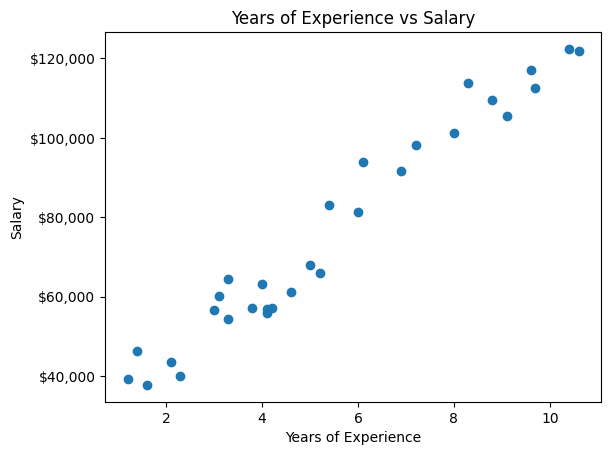

In [18]:
plt.scatter(X,y)
plt.xlabel("Years of Experience")
plt.ylabel("Salary")
plt.title("Years of Experience vs Salary")
plt.gca().yaxis.set_major_formatter(
    mtick.StrMethodFormatter('${x:,.0f}')
)
plt.show()



Look carefully at the scatterplot.

Consider:

- Is there a clear relationship between years of experience and salary?
- Is the relationship positive or negative?
- Does a straight line appear to be a reasonable model for this relationship?
- Is there variation in salary that years of experience alone cannot explain?

We will return to these questions after fitting and evaluating our model.

## E. Create Training and Test Sets

The goal of machine learning is not simply to fit the data we already have. We want a model that **generalizes** well to new, unseen data.

To evaluate generalization, we will divide the data into two parts:

- the **training set**, which will be used to fit the model; and
- the **test set**, which will be kept separate and used to evaluate the fitted model on unseen data.

We will use 80% of the observations for training and 20% for testing.

We will study data splitting in more detail later in the course. For now, the important principle is that **the test data must not be used to fit the model**.

In [19]:

X_train, X_test, y_train, y_test = train_test_split(X,y,test_size=0.20,random_state=random_seed
)

print("X_train shape:", X_train.shape)
print("X_test shape: ", X_test.shape)
print("y_train shape:", y_train.shape)
print("y_test shape: ", y_test.shape)

X_train shape: (24, 1)
X_test shape:  (6, 1)
y_train shape: (24,)
y_test shape:  (6,)


### Problem 3 Graded Answer

Set:

- `a3a` to the number of samples in the **training set**; and
- `a3b` to the number of samples in the **test set**.

Use expressions based on the data rather than entering the numbers directly.

In [20]:
# Your answers here, NOT in the next cell

a3a = X_train.shape[0]              # Replace with an expression that returns the number of training samples

In [21]:
# Graded Answer
# DO NOT change this cell in any way
# Be SURE to run this cell before submitting

print(f'a3a = {a3a}')

a3a = 24


In [22]:
# Your answers here, NOT in the next cell

a3b = X_test.shape[0]                # Replace with an expression that returns the number of test samples

In [23]:
# Graded Answer
# DO NOT change this cell in any way
# Be SURE to run this cell before submitting

print(f'a3b = {a3b}')

a3b = 6


## F. Fit a Linear Regression Model

Now we are ready to train our first machine learning model.

For simple linear regression, the model has the form

$$
\hat{y} = \beta_0 + \beta_1 X
$$

where:

- $\hat{y}$ is the predicted salary;
- $X$ is years of experience;
- $\beta_0$ is the **intercept**; and
- $\beta_1$ is the **slope**.

Scikit-Learn's `LinearRegression` model estimates the values of $\beta_0$ and $\beta_1$ from the **training data**.

Create a `LinearRegression` model called `model`, and then use `fit()` to train it using `X_train` and `y_train`.

In [24]:
model = LinearRegression().fit(X_train,y_train)


After fitting the model, Scikit-Learn stores the estimated intercept in `model.intercept_` and the estimated coefficients in `model.coef_`.

Because `model.coef_` contains one coefficient for each input feature, it is returned as a NumPy array. How do you extract the slope for this model? Examine `model.coef_` if this is unclear.

### Problem 4 Graded Answer

Using the fitted `model`, set:

- `a4a` to the fitted **intercept**; and
- `a4b` to the fitted **slope**.

Do not enter the numerical values directly. Use expressions that retrieve the values from the fitted model.

In [25]:
# Your answer here, NOT in the next cell

a4a = model.intercept_

In [26]:
# Graded Answer
# DO NOT change this cell in any way
# Be SURE to run this cell before submitting

print(f'a4a = ${a4a:,.2f}')

a4a = $24,380.20


In [27]:
# Your answer here, NOT in the next cell

a4b = model.coef_[0]          # Replace with an expression that returns the slope

In [28]:
# Graded Answer
# DO NOT change this cell in any way
# Be SURE to run this cell before submitting

print(f'a4b = ${a4b:,.2f}')

a4b = $9,423.82


## G. Visualize the Fitted Model

Now that the model has been trained, we can visualize the relationship it learned.

First, use `predict()` to calculate the model's predicted salaries for the values in `X_train`.

In [29]:
# Your code here

y_train_pred = model.predict(X_train)

### G.1 Plot the Fitted Model

Create a plot that shows:

- the **training observations** as a scatterplot; and
- the model's **predicted values** as a line.

You already calculated the predicted training values in `y_train_pred`.

Because `train_test_split()` shuffled the observations, the rows of `X_train` are not necessarily ordered by years of experience. Before plotting the regression line, sort the observations by the feature value.

> **Hint:** The following expression gives the indices that would sort the training observations by years of experience:
>
> ```python
> order = np.argsort(X_train["YearsExperience"])
> ```

Your plot should include appropriate axis labels, a title, and a legend.

Text(0.5, 1.0, 'Years of Experience vs Salary')

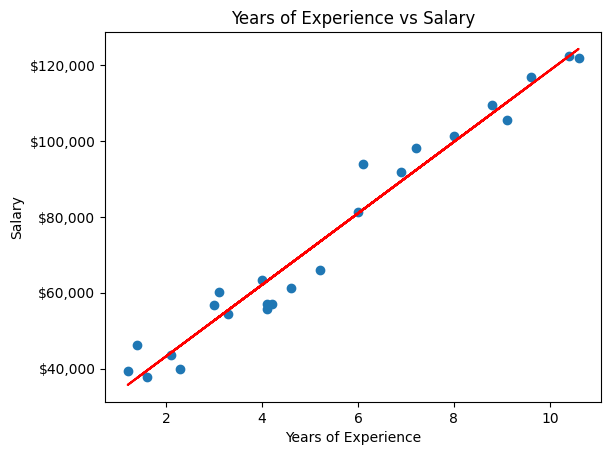

In [30]:
# Your code phere
order = np.argsort(X_train["YearsExperience"])
plt.scatter(X_train,y_train)
plt.plot(X_train,y_train_pred,color='red')
plt.gca().yaxis.set_major_formatter(mtick.StrMethodFormatter('${x:,.0f}'))
plt.xlabel("Years of Experience")
plt.ylabel("Salary")
plt.title("Years of Experience vs Salary")

Notice that the fitted line does not pass through every observation. The model captures the overall relationship between years of experience and salary, but individual salaries vary around that relationship.

This difference between the observed values and the model's predictions is the **prediction error**.

In the next section, we will measure that error and, most importantly, determine how well the model performs on data it did **not** see during training.

## H. Evaluate the Model

The fitted line gives us a visual picture of the model, but we also need a numerical way to measure prediction error.

We will use **Mean Absolute Error (MAE)**, which measures the average absolute difference between the observed values and the model's predictions.

Because salary is measured in dollars, MAE is also measured in **dollars**, which makes it easy to interpret.

You already calculated the model's predictions for the training data in `y_train_pred`.

Now use the fitted model to generate predictions for the **test set**, which the model did not see during training.

Store the predictions in `y_test_pred`.

In [31]:
# Your code here

y_test_pred = model.predict(X_test)

### Problem 5 Graded Answer

Set:

- `a5a` to the **training MAE**; and
- `a5b` to the **test MAE**.

Use expressions based on the appropriate observed and predicted values. Do not enter the numerical values directly.

**Hint:** `mean_absolute_error()` takes the observed values as its first argument and the predicted values as its second argument.

In [50]:
# Your answer here, NOT in the next cell

a5a = mean_absolute_error(y_train, y_train_pred)

In [51]:
# Graded Answer
# DO NOT change this cell in any way
# Be SURE to run this cell before submitting

print(f'a5a = ${a5a:,.2f}')

a5a = $4,221.05


In [52]:
# Your answer here, NOT in the next cell

a5b = mean_absolute_error(y_test, y_test_pred)

In [53]:
# Graded Answer
# DO NOT change this cell in any way
# Be SURE to run this cell before submitting

print(f'a5b = ${a5b:,.2f}')

a5b = $6,286.45


The **training MAE** tells us how closely the model fits the data used to train it.

The **test MAE** gives us an estimate of how accurately the model may predict salary for new observations drawn from the same population.

## I. Make a Prediction for a New Employee

One of the main purposes of a machine learning model is to make predictions for new observations.

Suppose a new employee has **7.5 years of experience**.

Use the fitted model to predict this employee's salary.

Remember that Scikit-Learn expects the input to have the same feature structure as the data used to train the model.

### Problem 6 Graded Answer

Set `a6` to the model's predicted salary for an employee with **7.5 years of experience**.

Do not calculate the prediction by hand from the slope and intercept. Use the fitted model's `predict()` method.

**Hint:** You can create a one-row DataFrame with:

```python
pd.DataFrame({
    "YearsExperience": [7.5]
})

In [55]:
# Your answer here, NOT in the next cell

new_empoyee  = pd.DataFrame({
    "YearsExperience": [7.5]
})

a6 = model.predict(new_empoyee)[0]

In [61]:
# Graded Answer
# DO NOT change this cell in any way
# Be SURE to run this cell before submitting

print(f'a6 = ${a6:,.2f}')

a6 = $95,058.82


## Problem 7 Graded Answer — Multiple-Choice Concept Questions

Answer each of the following multiple-choice questions by setting the corresponding answer variable to the **number of the best answer**.

### Problem 7(a)

Why is this problem an example of **supervised regression**?

1. Because the model groups employees into categories without known outcomes.
2. Because the model predicts a numerical target from labeled examples.
3. Because the model uses only one input feature.
4. Because linear regression always requires a test set.

In [62]:
# Your answer here, NOT in the next cell

a7a = 2

In [63]:
# Graded Answer
# DO NOT change this cell in any way
# Be SURE to run this cell before submitting

print(f'a7a = {a7a}')

a7a = 2


### Problem 7(b)

What is the primary purpose of the **test set** in this homework?

1. To improve the fitted slope and intercept.
2. To provide additional observations for training.
3. To estimate how well the model generalizes to unseen data.
4. To remove unusual observations before fitting the model.

In [64]:
# Your answer here, NOT in the next cell

a7b = 3

In [65]:
# Graded Answer
# DO NOT change this cell in any way
# Be SURE to run this cell before submitting

print(f'a7b = {a7b}')

a7b = 3


### Problem 7(c)

Suppose the fitted slope is approximately **$9,400 per year**.

What does this mean?

1. Every employee earns exactly \$9,400 more than the previous employee.
2. The model predicts salary increases by about \$9,400 for each additional year of experience.
3. The average salary in the dataset is approximately \$9,400.  
4. The model's average prediction error is approximately \$9,400.

In [66]:
# Your answer here, NOT in the next cell

a7c = 2

In [67]:
# Graded Answer
# DO NOT change this cell in any way
# Be SURE to run this cell before submitting

print(f'a7c = {a7c}')

a7c = 2


### Problem 7(d)

Suppose the test MAE is approximately **$6,300**.

What is the best interpretation?

1. Every test prediction is wrong by exactly \$6,300.
2. The model underpredicts salary by \$6,300 for every employee.
3. The model's predictions differ from the observed test salaries by about \$6,300 on average.
4. The average salary in the test set is \$6,300.

In [68]:
# Your answer here, NOT in the next cell

a7d = 3

In [69]:
# Graded Answer
# DO NOT change this cell in any way
# Be SURE to run this cell before submitting

print(f'a7d = {a7d}')

a7d = 3


### Problem 7(e)

Why should we not expect years of experience alone to predict salary perfectly?

1. Linear regression cannot make numerical predictions.
2. Salary may depend on other factors and on variation that the model cannot capture.
3. A test set always causes prediction error.
4. The fitted slope must be zero for a perfect model.

In [70]:
# Your answer here, NOT in the next cell

a7e = 2

In [71]:
# Graded Answer
# DO NOT change this cell in any way
# Be SURE to run this cell before submitting

print(f'a7e = {a7e}')

a7e = 2


## Problem 8 Graded Answer — Reflection

In a short paragraph, discuss what this model tells us about the relationship between years of experience and salary, and what its limitations are.

Your response should address:

- what the fitted model suggests about the relationship between experience and salary;
- what the test MAE tells us about prediction accuracy; and
- why years of experience alone cannot determine salary exactly.


In [72]:
# Your answer here, NOT in the next cell

a8 = """
There is postive relationship between years of experience and salary.
The intercept around $24,380 means that, the model predicts a starting salary close to the intercept with 0 years of experience
and the slope of around $9,424 per year indicates an increase of $9,424 for each year of experience obtained.
The scatter plot illustrates this as the points shows an upward trend and the fitted model clearly shows this trend as well.
The MAE of about $6,286 means that, on average, the predicted salary by the model differs from the actual test of about $6,286.
Given the level of salaries, the model is good but not precise. This margin of error exist because, just years of experience cannot
fully determine salary also depends on other factors such as level of education, industry, type of job, compny, performance, etc.
So even a very good model cannot predict salary perfectly an there will defienetly be some margin of error.
"""

In [73]:
# Graded Answer
# DO NOT change this cell in any way
# Be SURE to run this cell before submitting

print("a8 =")
print(a8)

a8 =

There is postive relationship between years of experience and salary.
The intercept around $24,380 means that, the model predicts a starting salary close to the intercept with 0 years of experience 
and the slope of around $9,424 per year indicates an increase of $9,424 for each year of experience obtained. 
The scatter plot illustrates this as the points shows an upward trend and the fitted model clearly shows this trend as well.
The MAE of about $6,286 means that, on average, the predicted salary by the model differs from the actual test of about $6,286. 
Given the level of salaries, the model is good but not precise. This margin of error exist because, just years of experience cannot 
fully determine salary also depends on other factors such as level of education, industry, type of job, compny, performance, etc. 
So even a very good model cannot predict salary perfectly an there will defienetly be some margin of error.

